# HR Workforce Analysis

An end-to-end HR data analysis project built in Python, covering data cleaning,
exploratory data analysis, and business insight generation across 1000+ employee records.

## What This Project Does
- Cleans and preprocesses a messy HR dataset (nulls, splits, feature engineering)
- Explores salary, age, tenure, and performance distributions through visualizations
- Answers 15+ business questions across attrition, compensation, and performance
- Delivers actionable insights for HR decision-making

## Tech Stack
- Python, Pandas, NumPy, Matplotlib, Seaborn

## Structure

hr-analysis/ \
├── data/ \
│   └── messy_dataset.csv \
├── plots/ \
│   └── *.png \
├── report/ \
│   └── hr_analysis.pdf \
├── hr_analysis.ipynb \
├── requirements.txt \
└── .gitignore

## Key Findings
- Finance has the highest turnover rate (36.47% of dept)
- Salary is disconnected from performance — poor performers occupy High salary bands
- Employees peak in performance at 3-5 years tenure
- Region, not role, drives pay — a clear equity issue
- Remote work has no negative impact on performance

# 🟢 1. Data Loading and Cleaning

In [6]:
import os
import pandas as pd
import numpy as np
from datetime import datetime, date, time

BASE_DIR = os.getcwd()
csv_path = os.path.join(BASE_DIR, "data", "hr_dataset.csv")
df = pd.read_csv(csv_path, parse_dates=["Join_Date"])
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,2021-04-02,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,2020-07-10,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,2023-12-07,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,2021-11-27,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,2022-01-05,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Employee_ID        1020 non-null   str           
 1   First_Name         1020 non-null   str           
 2   Last_Name          1020 non-null   str           
 3   Age                809 non-null    float64       
 4   Department_Region  1020 non-null   str           
 5   Status             1020 non-null   str           
 6   Join_Date          1020 non-null   datetime64[us]
 7   Salary             996 non-null    float64       
 8   Email              1020 non-null   str           
 9   Phone              1020 non-null   int64         
 10  Performance_Score  1020 non-null   str           
 11  Remote_Work        1020 non-null   bool          
dtypes: bool(1), datetime64[us](1), float64(2), int64(1), str(7)
memory usage: 88.8 KB


Dropping contact columns (not needed in analysis)

In [3]:
df = df.drop(['Email', 'Phone'], axis=1)

Filling Age with medians

In [4]:
df.Age = df.Age.fillna(df.Age.median()).astype(int)

Creating column (Years_at_Company)

In [5]:
today = pd.to_datetime(date.today())
total_time = round((today - df.Join_Date).dt.days / 365, 2)
df["Years_at_Company"] = total_time

Splitting Department/Region into separate columns (dropping the combined one)

In [6]:
df[["Department", "Region"]] = df.Department_Region.str.split("-", expand=True)
df = df.drop("Department_Region", axis=1)

Filling Null Salaries with means for each department

In [7]:
df['Salary'] = df['Salary'].fillna(df.groupby('Department')['Salary'].transform('mean'))

Making a Salary Band column based on quantiles of salaries (Low, Mid, High) - (tertiles: 0-33%, 33-66%, 66-100%)

In [8]:
df['Salary_Band'] = pd.qcut(df['Salary'], q=3, labels=['Low', 'Mid', 'High'])

Creating High Performer Column with Boolean values

In [9]:
df["Is_High_Performer"] = df.Performance_Score == "Excellent"

# 🟢 2. EDA (Exploratory Data Analysis)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

### Histogram

Salary distribution

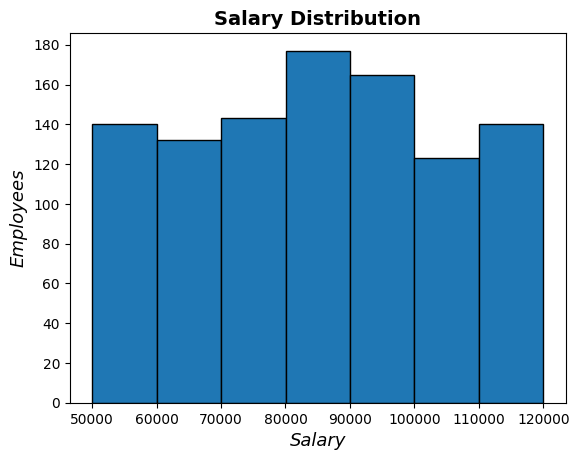

In [11]:
plt.hist(x=df.Salary, bins=7, edgecolor='black')
plt.title("Salary Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Salary", fontsize=13, fontstyle='italic')
plt.ylabel("Employees", fontsize=13, fontstyle='italic')
plt.xticks(np.arange(50000, 120001, 10000))
plt.yticks(np.arange(0, 181, 20))
plt.savefig("plots/salary_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Age distribution

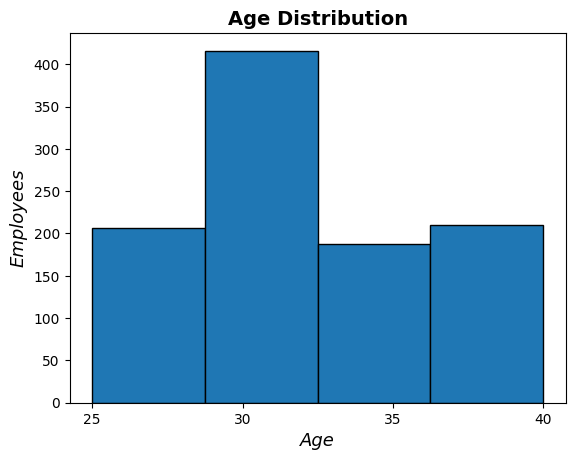

In [12]:
plt.hist(x=df.Age, bins=4, edgecolor='black')
plt.title("Age Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=13, fontstyle='italic')
plt.ylabel("Employees", fontsize=13, fontstyle='italic')
plt.xticks(np.array(df.Age.unique()))
plt.savefig("plots/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Boxplot

Salary by Department

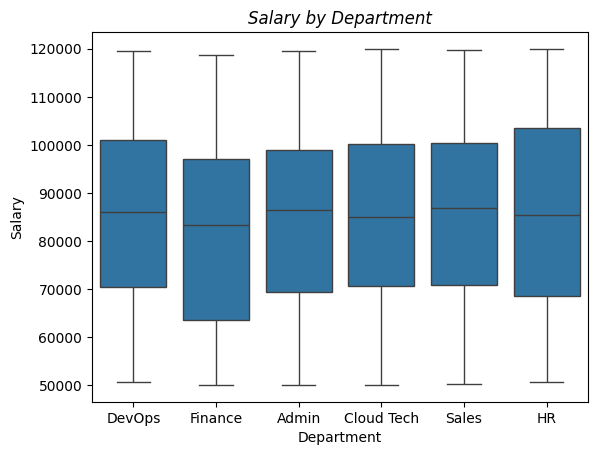

In [13]:
sns.boxplot(data=df, x='Department', y='Salary')
plt.title('Salary by Department', fontstyle='italic')
plt.suptitle('')
plt.savefig("plots/salary_by_department.png", dpi=300, bbox_inches="tight")
plt.show()

Salary by Performance_Score

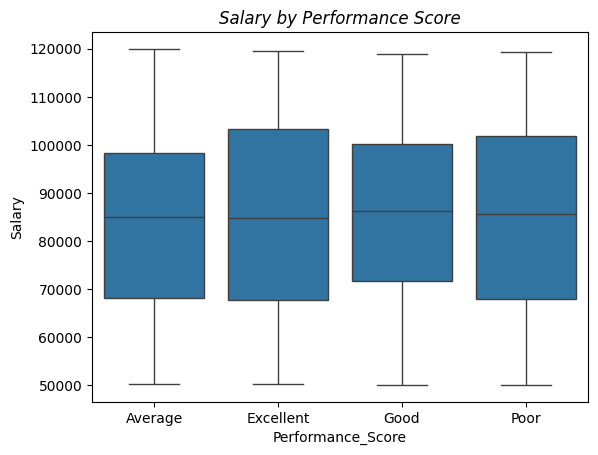

In [14]:
sns.boxplot(data=df, x='Performance_Score', y='Salary')
plt.title('Salary by Performance Score', fontstyle='italic')
plt.suptitle('')
plt.savefig("plots/salary_by_performance.png", dpi=300, bbox_inches="tight")
plt.show()

### Countplot

Performance_Score

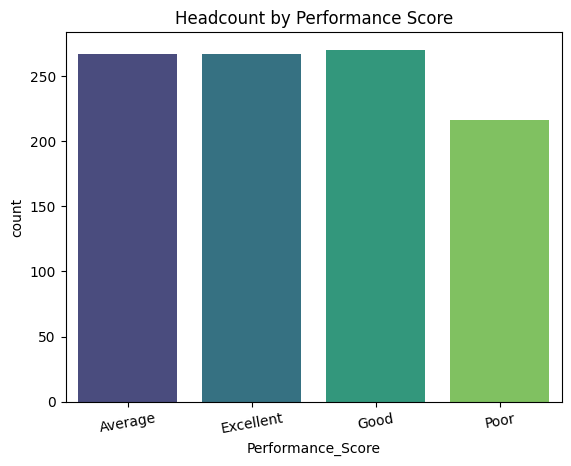

In [15]:
sns.countplot(data=df, x='Performance_Score', palette='viridis', hue='Performance_Score')
plt.title('Headcount by Performance Score')
plt.xticks(rotation=10)
plt.savefig("plots/performance_score_count.png", dpi=300, bbox_inches="tight")
plt.show()

Status along with performance score

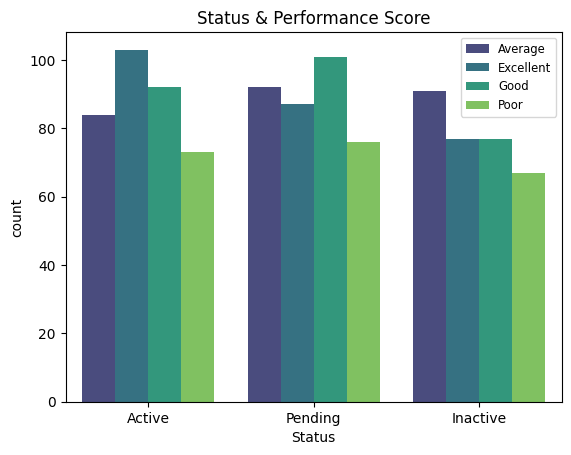

In [16]:
sns.countplot(data=df, x='Status', palette='viridis', hue='Performance_Score')
plt.legend(fontsize='small')
plt.title('Status & Performance Score')
plt.savefig("plots/status_performance_count.png", dpi=300, bbox_inches="tight")
plt.show()

Remote_Work

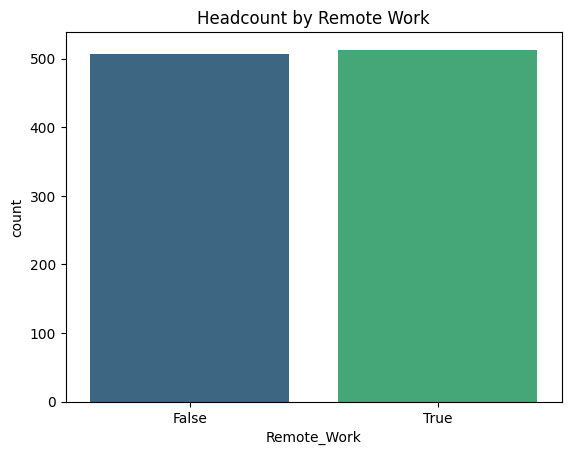

In [17]:
sns.countplot(data=df, x='Remote_Work', palette='viridis', hue='Remote_Work', legend=False)
plt.title('Headcount by Remote Work', fontsize=12)
plt.savefig("plots/remotework_count.png", dpi=300, bbox_inches="tight")
plt.show()

### Scatterplot

Age vs Salary

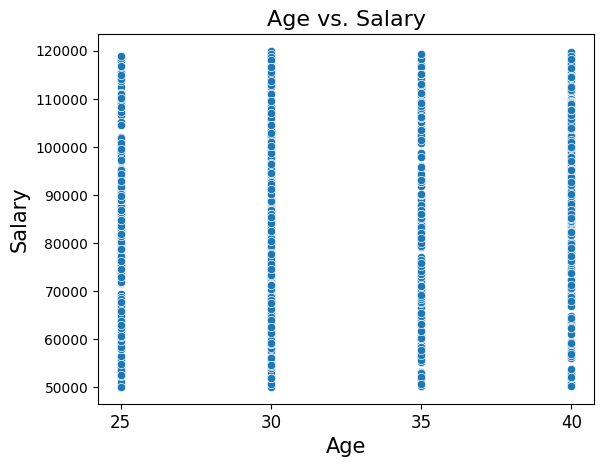

In [18]:
ax = sns.scatterplot(data=df, x='Age', y='Salary')
ax.tick_params(axis='x', labelsize=12)
plt.xticks(df.Age.unique())
plt.xlabel('Age', fontsize=15)
plt.ylabel('Salary', fontsize=15)
plt.title("Age vs. Salary", fontsize=16)
plt.savefig("plots/age_vs_salary.png", dpi=300, bbox_inches="tight")
plt.show()


Years_at_Company vs Salary

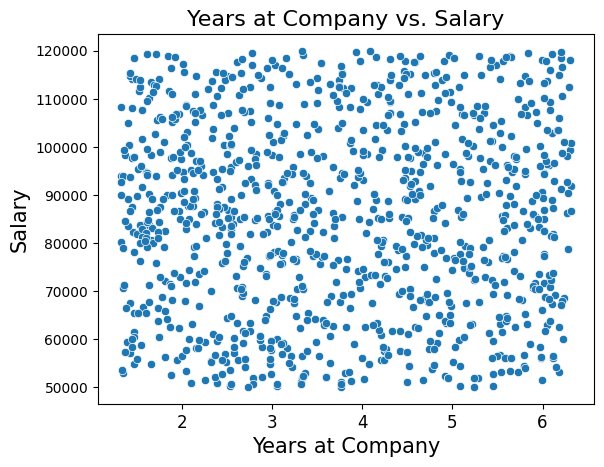

In [19]:
ax = sns.scatterplot(data=df, x='Years_at_Company', y='Salary')
ax.tick_params(axis='x', labelsize=12)
plt.xlabel('Years at Company', fontsize=15)
plt.ylabel('Salary', fontsize=15)
plt.title("Years at Company vs. Salary", fontsize=16)
plt.savefig("plots/years_vs_salary.png", dpi=300, bbox_inches="tight")
plt.show()

### Heatmap (correlation)

Only numeric: Age, Salary, Years_at_Company

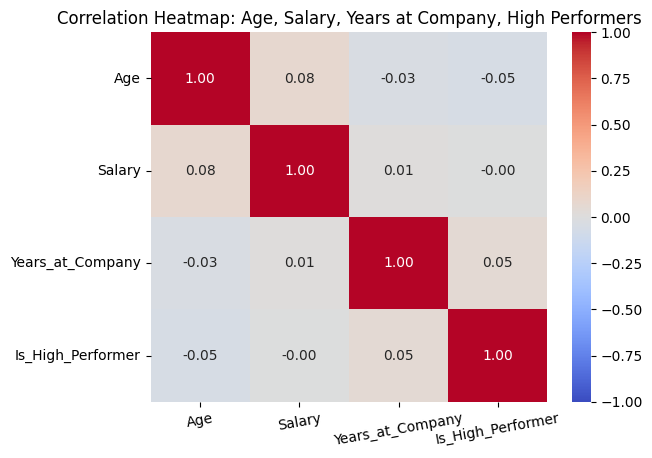

In [20]:
corr_matrix = df[['Age', 'Salary', 'Years_at_Company', 'Is_High_Performer']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap: Age, Salary, Years at Company, High Performers")
plt.xticks(rotation=10)
plt.savefig("plots/heatmap_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

# 🟢 3. HR Analysis

In [21]:
# for convesion of ratios into proper form
from fractions import Fraction

def to_ratio(x):
    fraction = Fraction(x).limit_denominator()
    return f"{fraction.numerator}:{fraction.denominator}"

### Workforce Overview

Relation between Age and Status

In [22]:
pd.crosstab(df['Age'], df['Status'], margins=True)

Status,Active,Inactive,Pending,All
Age,,,,
25,83,61,62,206
30,147,125,144,416
35,59,56,73,188
40,63,70,77,210
All,352,312,356,1020


Relation between Salary Bands and Status

In [23]:
pd.crosstab(df['Salary_Band'], df['Status'])

Status,Active,Inactive,Pending
Salary_Band,,,
Low,113,108,119
Mid,123,110,107
High,116,94,130


Relation between Performance Scores and Status

In [24]:
pd.crosstab(df['Performance_Score'], df['Status'])

Status,Active,Inactive,Pending
Performance_Score,,,
Average,84,91,92
Excellent,103,77,87
Good,92,77,101
Poor,73,67,76


### Attrition Analysis

Which department has the highest turnover rate?

In [25]:
gb = df.groupby('Status')['Department'].value_counts()
print(f"Finance Department has highest turnover rate with 62 inactive employees esp. in Low and Mid salary bands. It comprises {round(62/170 *100, 2)} % of total employees in this dept.")
print("INSIGHT: Finance department needs stablization by handling high number of resigns.")
gb.Inactive

Finance Department has highest turnover rate with 62 inactive employees esp. in Low and Mid salary bands. It comprises 36.47 % of total employees in this dept.
INSIGHT: Finance department needs stablization by handling high number of resigns.


Department
Finance       62
DevOps        58
Admin         51
Sales         50
HR            49
Cloud Tech    42
Name: count, dtype: int64

Are high performers leaving more than low performers? (that's a crisis if yes)

In [26]:
ct = pd.crosstab(index=df.Is_High_Performer, columns=df.Status)
print("No! low performers are leaving more than high performers")
print("low performers left: 235")
print("high performers left: 77")
print("INSIGHT: Low performing workers are more likely to leave than high performers")
print(f"\nDifference between active and inactive employees: \n{ct.Active - ct.Inactive}, \nThere's a big difference between active/inactive High Performers as compared to Low Performing ones.")

No! low performers are leaving more than high performers
low performers left: 235
high performers left: 77
INSIGHT: Low performing workers are more likely to leave than high performers

Difference between active and inactive employees: 
Is_High_Performer
False    14
True     26
dtype: int64, 
There's a big difference between active/inactive High Performers as compared to Low Performing ones.


Do remote workers stay longer than on-site?

In [28]:
# Bin years into tenure groups first
df['Tenure_Group'] = pd.cut(df['Years_at_Company'], 
                             bins=[0, 2, 5, 10, 100], 
                             labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs'])

gb = df.groupby(['Remote_Work'])[['Tenure_Group']].value_counts()

remote = gb[True]['6-10 yrs']
onsite = gb[False]['6-10 yrs']

print("In tenure group of 6-10 yrs, there are: \n128 remote and 134 on-site workers")
print("INSIGHT: On-Site workers stay longer than remote workers")
gb

In tenure group of 6-10 yrs, there are: 
128 remote and 134 on-site workers
INSIGHT: On-Site workers stay longer than remote workers


Remote_Work  Tenure_Group
False        3-5 yrs         305
             6-10 yrs        134
             0-2 yrs          68
             10+ yrs           0
True         3-5 yrs         299
             6-10 yrs        128
             0-2 yrs          86
             10+ yrs           0
Name: count, dtype: int64

Is there a salary band where people quit the most?

In [29]:
ct = pd.crosstab(index=df.Salary_Band, columns=df.Status)
print("People resign the most in Mid and then Low band salaries with 110 and 108 headcounts each")
print("INSIGHT: Employees are more likely to leave in low and mid band salary than in high band")
ct.Inactive

People resign the most in Mid and then Low band salaries with 110 and 108 headcounts each
INSIGHT: Employees are more likely to leave in low and mid band salary than in high band


Salary_Band
Low     108
Mid     110
High     94
Name: Inactive, dtype: int64

Which region retains employees the best?

In [30]:
ct = pd.crosstab(index=df.Region, columns=df.Status).sort_values(by='Active', ascending=False)
ct['ratio'] = (ct.Active / ct.Inactive).round(2)
print("New York, California and then Illinois stand the best at retaining employees with their excellent active to inactive ratios")
print("INSIGHT: Florida and Nevada are at the lowest in retaining employees and need pragmatic approach to fix this turnover")
ct.sort_values(by='ratio', ascending=False)

New York, California and then Illinois stand the best at retaining employees with their excellent active to inactive ratios
INSIGHT: Florida and Nevada are at the lowest in retaining employees and need pragmatic approach to fix this turnover


Status,Active,Inactive,Pending,ratio
Region,,,,
New York,61,38,62,1.61
California,69,53,65,1.30
Illinois,61,50,54,1.22
Texas,51,45,57,1.13
Nevada,55,59,55,0.93
Florida,55,67,63,0.82


### Compensation Analysis

Are high performers actually paid more, or is salary disconnected from performance?

In [31]:
ct = pd.crosstab(index=[df.Is_High_Performer], columns=[df.Salary_Band])
ct1 = pd.crosstab(index=[df.Performance_Score], columns=[df.Salary_Band])

print(f"Even though the number of high performers with high salaries is [96] greater than with low [90] and mid [81] salary bands")
print(f"Also, [73] poor performance workers are getting high band salary which is unfair. So Yes! salary is disconnected from performance")
print("INSIGHT: Salaries of High performers should be raised and of Poor performers must be lowered.")
ct1

Even though the number of high performers with high salaries is [96] greater than with low [90] and mid [81] salary bands
Also, [73] poor performance workers are getting high band salary which is unfair. So Yes! salary is disconnected from performance
INSIGHT: Salaries of High performers should be raised and of Poor performers must be lowered.


Salary_Band,Low,Mid,High
Performance_Score,,,
Average,91,93,83
Excellent,90,81,96
Good,82,100,88
Poor,77,66,73


Does the same role/department pay differently across regions? (pay equity issue)

In [32]:
gb = df.groupby('Department')[['Region', 'Salary_Band']]
gb.get_group('Admin').value_counts()


pivot = df.pivot_table(index=['Department', 'Region'], columns='Salary_Band', values='Employee_ID', aggfunc='count', fill_value=0)
bands = ['Low', 'Mid', 'High']
pivot['Dominant_Band'] = pivot[bands].idxmax(axis=1)
pivot['Insight'] = 'Mostly ' + pivot['Dominant_Band'].astype(str)
pivot = pivot.drop('Dominant_Band', axis=1)

print("As shown in the table, pay equity varies significantly by geography. For the same department, we see polar opposite pay structures. For example, Admin roles in Nevada are predominantly in the Low band (17 employees), whereas in Illinois, nthe majority are in the High band (15 employees). This confirms that region is a primary driver of salary banding rather than department alone.")
print("INSIGHT: Employees in the same role are paid very differently based on their region, not their performance — this needs to be fixed.")
pivot

As shown in the table, pay equity varies significantly by geography. For the same department, we see polar opposite pay structures. For example, Admin roles in Nevada are predominantly in the Low band (17 employees), whereas in Illinois, nthe majority are in the High band (15 employees). This confirms that region is a primary driver of salary banding rather than department alone.
INSIGHT: Employees in the same role are paid very differently based on their region, not their performance — this needs to be fixed.


Salary_Band            Low  Mid  High      Insight
Department Region                                 
Admin      California   10   11    13  Mostly High
           Florida       7   11     7   Mostly Mid
           Illinois      5    9    15  Mostly High
           Nevada       17    8     9   Mostly Low
           New York      9    8     5   Mostly Low
           Texas         8    8     6   Mostly Low
Cloud Tech California    8   12     9   Mostly Mid
           Florida       6    8    14  Mostly High
           Illinois      5    5     6  Mostly High
           Nevada        8    4     8   Mostly Low
           New York     10    8     6   Mostly Low
           Texas         9   10    10   Mostly Mid
DevOps     California   10   19     6   Mostly Mid
           Florida      10   12    12   Mostly Mid
           Illinois     10   14     9   Mostly Mid
           Nevada        5    9    13  Mostly High
           New York     12    8    13  Mostly High
           Texas         8   11     8   Mostly Mid
Finance    California    9   12    11   Mostly Mid
           Florida       7   10     7   Mostly Mid
           Illinois     19    9     5   Mostly Low
           Nevada       14    9     6   Mostly Low
           New York      8    6     9  Mostly High
           Texas         9   12     8   Mostly Mid
HR         California    6   10    10   Mostly Mid
           Florida      20    8    13   Mostly Low
           Illinois      8    6    10  Mostly High
           Nevada        8    7     9  Mostly High
           New York     14    6    13   Mostly Low
           Texas         6    8     9  Mostly High
Sales      California   10   10    11  Mostly High
           Florida       9    9    15  Mostly High
           Illinois      9   12     9   Mostly Mid
           Nevada       10   15    10   Mostly Mid
           New York      9    7    10  Mostly High
           Texas         8    9     6   Mostly Mid

Are senior employees (high years) stuck in low salary bands? (promotion stagnation)

In [33]:
print("Based on the data provided, there is no evidence of promotion stagnation, as employees with 6-10 years of tenure are evenly distributed across low, mid, and high salary bands, rather than concentrated in low bands.")
print("INSIGHT: Tenure does not translate to higher pay. Salary bands remain flat across all experience levels, meaning long-serving employees are not being rewarded for loyalty or seniority, which quietly fuels attrition.")

ct = pd.crosstab(df['Tenure_Group'], df['Salary_Band'])
print(ct)

Based on the data provided, there is no evidence of promotion stagnation, as employees with 6-10 years of tenure are evenly distributed across low, mid, and high salary bands, rather than concentrated in low bands.
INSIGHT: Tenure does not translate to higher pay. Salary bands remain flat across all experience levels, meaning long-serving employees are not being rewarded for loyalty or seniority, which quietly fuels attrition.
Salary_Band   Low  Mid  High
Tenure_Group                
0-2 yrs        47   56    51
3-5 yrs       205  202   197
6-10 yrs       88   82    92


### Performance Analysis

Which department produces the most high performers?

In [34]:
print("HR, Sales and DevOps department produces the most high performers")
print("INSIGHT: HR and Sales lead in high performers, but their non-performer counts are disproportionately high. DevOps has the worst ratio, meaning only 1 in 4 employees there is a top performer, signaling a talent quality issue.")
ct = pd.crosstab(df.Department, df.Is_High_Performer).sort_values(by=True, ascending=False)
ct['ratio'] = (ct[False] / ct[True]).round(2)
ct['Ratio'] = ct.ratio.map(to_ratio)
ct[:3]

HR, Sales and DevOps department produces the most high performers
INSIGHT: HR and Sales lead in high performers, but their non-performer counts are disproportionately high. DevOps has the worst ratio, meaning only 1 in 4 employees there is a top performer, signaling a talent quality issue.


Is_High_Performer,False,True,ratio,Ratio
Department,,,,
HR,120,51,2.35,47:20
Sales,128,50,2.56,64:25
DevOps,142,47,3.02,151:50


Does remote work help or hurt performance scores?

In [35]:
print("Remote workers has negligibly low difference with on-site workers when it comes to high performing people.")
print("INSIGHT: Remote work has no meaningful impact on performance. Output is consistent regardless of location, making remote work a low-risk, high-reward retention tool.")
pd.crosstab(df.Remote_Work, df.Is_High_Performer)

Remote workers has negligibly low difference with on-site workers when it comes to high performing people.
INSIGHT: Remote work has no meaningful impact on performance. Output is consistent regardless of location, making remote work a low-risk, high-reward retention tool.


Is_High_Performer,False,True
Remote_Work,,
False,371,136
True,382,131


Do younger or older employees perform better?

In [36]:
print("High performing Workers under 35 are 175 and over 35 are only 92, which shows a clear difference in performance affected by age.")
print("INSIGHT: Employees under 35 show a higher concentration of top performance in this dataset.")

ct = pd.crosstab(df.Age, df.Is_High_Performer)
ct['ratio'] = (ct[False] / ct[True]).round(2)
ct['Ratio'] = ct.ratio.map(to_ratio)
ct

High performing Workers under 35 are 175 and over 35 are only 92, which shows a clear difference in performance affected by age.
INSIGHT: Employees under 35 show a higher concentration of top performance in this dataset.


Is_High_Performer,False,True,ratio,Ratio
Age,,,,
25,151,55,2.75,11:4
30,296,120,2.47,247:100
35,140,48,2.92,73:25
40,166,44,3.77,377:100


Is there a tenure sweet spot where performance peaks?

In [37]:
print(f"Yes, employees in tenure group of 3-6 yrs are high performers more than other tenure groups combined.")
print(f"High Performers in 0-2 yrs and 6-10 yrs Tenure: 104  <  in 3-5 yrs Tenure: 163")
print("INSIGHT: Employees hit their performance peak at 3-5 years, experienced enough to deliver, not yet disengaged. Retention efforts should prioritize this window before it's lost.")

ct = pd.crosstab(df.Tenure_Group, df.Is_High_Performer)
ct['ratio'] = (ct[False] / ct[True]).round(2)
ct['Ratio'] = ct.ratio.map(to_ratio)
ct['mul'] = ct[True] / ct[False]
ct

Yes, employees in tenure group of 3-6 yrs are high performers more than other tenure groups combined.
High Performers in 0-2 yrs and 6-10 yrs Tenure: 104  <  in 3-5 yrs Tenure: 163
INSIGHT: Employees hit their performance peak at 3-5 years, experienced enough to deliver, not yet disengaged. Retention efforts should prioritize this window before it's lost.


Is_High_Performer,False,True,ratio,Ratio,mul
Tenure_Group,,,,,
0-2 yrs,119,35,3.40,17:5,0.294118
3-5 yrs,441,163,2.71,271:100,0.369615
6-10 yrs,193,69,2.80,14:5,0.357513


### Workforce Structure

What's the age distribution per department — is any team aging out?

In [38]:
ct = pd.crosstab(df.Department, df.Age)

ct_age = ct.idxmax(axis=1).median()
ct_top = ct.sum().loc[ct_age]       # 416 employees being 30y old
print(f"It's evident from the data that a vast majority lies in the {ct_age} years of age in every department.")
print(f"With 416 Employees being 30y old spanning {round(ct_top/ct.sum().sum() * 100, 2)} % of the total staff.")
print("INSIGHT: The workforce is heavily concentrated at age 30, with no department aging out. But this uniformity suggests a future retirement cliff if hiring doesn't diversify across age groups now.")
ct

It's evident from the data that a vast majority lies in the 30.0 years of age in every department.
With 416 Employees being 30y old spanning 40.78 % of the total staff.
INSIGHT: The workforce is heavily concentrated at age 30, with no department aging out. But this uniformity suggests a future retirement cliff if hiring doesn't diversify across age groups now.


Age,25,30,35,40
Department,,,,
Admin,38,64,32,32
Cloud Tech,32,62,23,29
DevOps,34,82,39,34
Finance,32,60,36,42
HR,30,80,28,33
Sales,40,68,30,40
